# Evaluation — Guitar Make/Model Classifier

Loads the trained EfficientNet-B0 checkpoint and evaluates it on the **held-out
test split** (group-aware, by listing). Produces the numbers and plots reported
in the README:

1. Overall test accuracy + a majority-class baseline
2. Per-class precision / recall / F1 (`classification_report`)
3. Confusion matrix
4. A grid of example predictions with confidence bars

Everything is imported from the `strat_classifier` package — the same code used
to train — so this reflects the real model, not a re-implementation.

## 0. Setup

In [1]:
from collections import Counter
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from strat_classifier.data import make_dataloaders, IMAGENET_MEAN, IMAGENET_STD
from strat_classifier.inference import load_model, predict


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    return start

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data" / "images_labeled"
MODEL_DIR = REPO_ROOT / "models"
RESULT_DIR = REPO_ROOT / "results"
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("Repo root:", REPO_ROOT)
print("Device:", device)

Repo root: /Users/jeremymitaux/Desktop/reverb_project
Device: mps


## 1. Load the trained model

`load_model` reads `models/class_names.json` for the class ordering and rebuilds
the EfficientNet-B0 head, then loads `models/best_model.pt`.

In [2]:
model, class_names = load_model(MODEL_DIR)
model = model.to(device).eval()
print("Classes:", class_names)

Classes: ['stratocaster', 'telecaster']


## 2. Rebuild the test split

`make_dataloaders` uses the same seed and group-aware split as training, so the
test set here is exactly the held-out set the model never trained on.

In [3]:
train_loader, val_loader, test_loader, loader_classes = make_dataloaders(
    data_dir=DATA_DIR, batch_size=32, num_workers=0,
)
assert loader_classes == class_names, "class ordering mismatch between loader and checkpoint"
print(f"Train: {len(train_loader.dataset)}  "
      f"Val: {len(val_loader.dataset)}  "
      f"Test: {len(test_loader.dataset)}")

Train: 4310  Val: 952  Test: 933


## 3. Predict on the test set

In [4]:
@torch.no_grad()
def get_preds(model, loader, device):
    ys, ps = [], []
    for imgs, labels in loader:
        out = model(imgs.to(device))
        ps.extend(out.argmax(1).cpu().numpy())
        ys.extend(labels.numpy())
    return np.array(ys), np.array(ps)

y_true, y_pred = get_preds(model, test_loader, device)
acc = (y_true == y_pred).mean()

# Majority-class baseline: always guess the most common test label.
majority = Counter(y_true.tolist()).most_common(1)[0][1] / len(y_true)
print(f"Test images        : {len(y_true)}")
print(f"Test accuracy      : {acc:.3f}")
print(f"Majority baseline  : {majority:.3f}  (always guess '{class_names[Counter(y_true.tolist()).most_common(1)[0][0]]}')")
print(f"Lift over baseline : {acc - majority:+.3f}")

Test images        : 933
Test accuracy      : 0.952
Majority baseline  : 0.642  (always guess 'stratocaster')
Lift over baseline : +0.310


## 4. Per-class metrics

In [5]:
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

              precision    recall  f1-score   support

stratocaster      0.956     0.970     0.963       599
  telecaster      0.945     0.919     0.932       334

    accuracy                          0.952       933
   macro avg      0.950     0.945     0.947       933
weighted avg      0.952     0.952     0.952       933



## 5. Confusion matrix

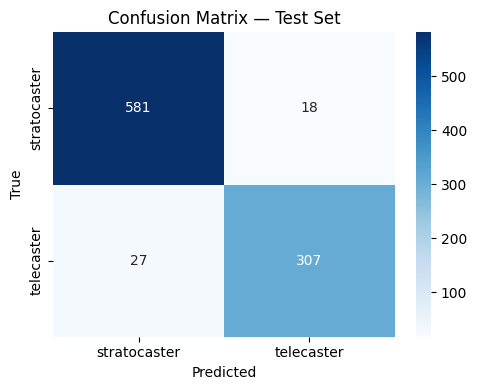

In [6]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
RESULT_DIR.mkdir(exist_ok=True)
fig.savefig(RESULT_DIR / "confusion_matrix.png", dpi=120)
plt.show()

## 6. Example predictions

A grid of test images with the predicted model and the model's confidence. Green
titles are correct, red are mistakes. This doubles as the prediction
visualization shown in the README.

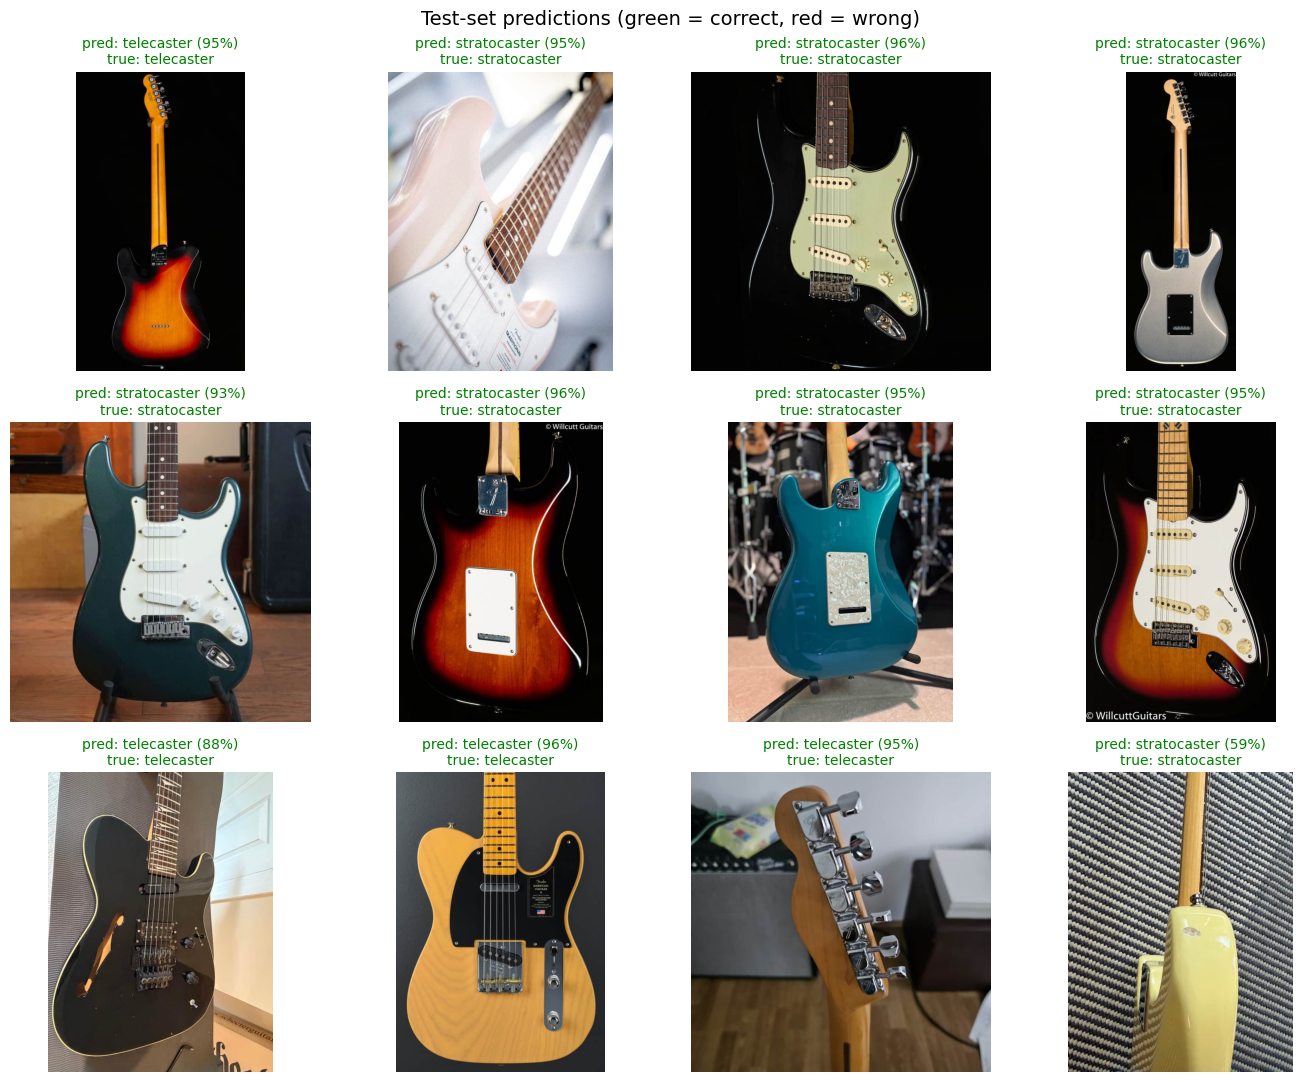

In [7]:
# Pull image paths + true labels straight from the test Subset.
test_ds = test_loader.dataset           # Subset over the eval ImageFolder
base = test_ds.dataset
samples = [base.samples[i] for i in test_ds.indices]

rng = np.random.default_rng(0)
pick = rng.choice(len(samples), size=min(12, len(samples)), replace=False)

fig, axes = plt.subplots(3, 4, figsize=(14, 11))
for ax, idx in zip(axes.flat, pick):
    path, true_label = samples[idx]
    res = predict(model.cpu(), class_names, path)
    from PIL import Image
    ax.imshow(Image.open(path).convert("RGB"))
    true_name = class_names[true_label]
    correct = res["prediction"] == true_name
    ax.set_title(f"pred: {res['prediction']} ({res['confidence']:.0%})\ntrue: {true_name}",
                 color="green" if correct else "red", fontsize=10)
    ax.axis("off")
for ax in axes.flat[len(pick):]:
    ax.axis("off")
model = model.to(device)   # move back
fig.suptitle("Test-set predictions (green = correct, red = wrong)", fontsize=14)
plt.tight_layout()
fig.savefig(RESULT_DIR / "example_predictions.png", dpi=120)
plt.show()

## Summary

The model is evaluated on the held-out, group-aware test split. The accuracy,
per-class F1, confusion matrix, and example predictions above are the figures
reported in the README's Results section.